In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import json
import os

print("All libraries loaded!")
print("TensorFlow version:", tf.__version__)

All libraries loaded!
TensorFlow version: 2.21.0


In [ ]:
data_path = "C:/plant-disease-ai/data/plantvillage dataset/color"
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Data ready!")

In [2]:
model.save("C:/plant-disease-ai/models/plant_disease_model.h5")
print("Model saved!")

NameError: name 'model' is not defined

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import json
import os

print("All libraries loaded!")
print("TensorFlow version:", tf.__version__)

All libraries loaded!
TensorFlow version: 2.21.0


In [2]:
data_path = "C:/plant-disease-ai/data/plantvillage dataset/color"
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Data ready!")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Data ready!


In [3]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(38, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model built successfully!")
print(f"Total layers: {len(model.layers)}")

Model built successfully!
Total layers: 157


In [4]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    verbose=1
)

print("\nTraining complete! 🎉")

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1138s 837ms/step - accuracy: 0.8143 - loss: 0.6496 - val_accuracy: 0.9111 - val_loss: 0.2941
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1719s 1s/step - accuracy: 0.8944 - loss: 0.3294 - val_accuracy: 0.9249 - val_loss: 0.2401
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 671s 494ms/step - accuracy: 0.9077 - loss: 0.2858 - val_accuracy: 0.9294 - val_loss: 0.2198
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 522s 384ms/step - accuracy: 0.9104 - loss: 0.2737 - val_accuracy: 0.9294 - val_loss: 0.2182
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 668s 492ms/step - accuracy: 0.9136 - loss: 0.2603 - val_accuracy: 0.9342 - val_loss: 0.2015
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 643s 473ms/step - accuracy: 0.9178 - loss: 0.2473 - val_accuracy: 0.9355 - val_loss: 0.1918
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 551s 406ms/step - accuracy: 0.9197 - loss: 0.2448 - val_accuracy: 0.9416 - val_loss: 0.1799
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 569s 419ms/step - acc

In [5]:
os.makedirs("C:/plant-disease-ai/models", exist_ok=True)
model.save("C:/plant-disease-ai/models/plant_disease_model.h5")
print("Model saved successfully!")

class_names = list(train_data.class_indices.keys())
with open("C:/plant-disease-ai/models/class_names.json", "w") as f:
    json.dump(class_names, f)

print(f"Class names saved! Total: {len(class_names)} classes")

Model saved successfully!
Class names saved! Total: 38 classes


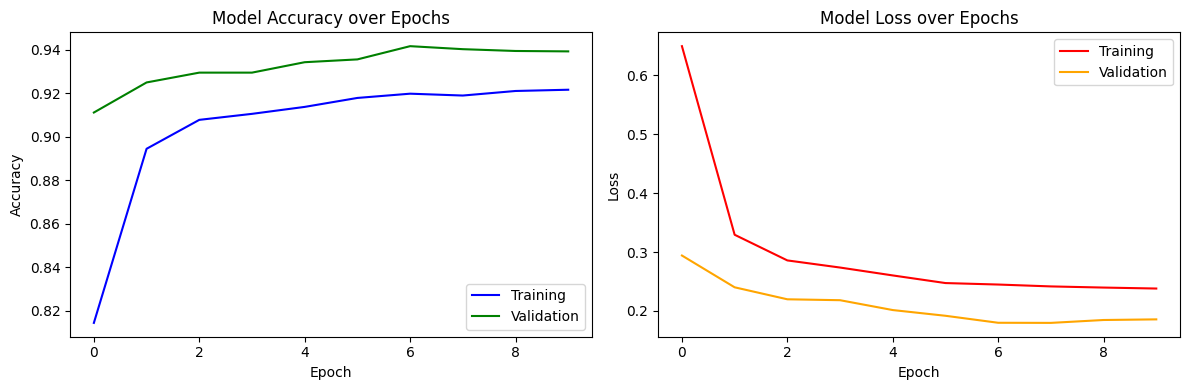

Graph saved!


In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation', color='green')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training', color='red')
plt.plot(history.history['val_loss'], label='Validation', color='orange')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("C:/plant-disease-ai/models/training_results.png")
plt.show()
print("Graph saved!")